In [1]:
import os
os.makedirs('results/eda_visualizations', exist_ok=True)
print("Folder created!")


Folder created!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('BankChurners.csv')

# Drop identifier column and separate features from target
X = df.drop(columns=['CLIENTNUM', 'Attrition_Flag'])
y = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Stratified Train/Test split first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 8101, Testing samples: 2026


In [4]:
# Select categorical columns that need to be converted to numeric
categorical_features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Fit each LabelEncoder strictly on X_train, then transform both splits
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train[col])
    X_test_encoded[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Print verification of encoded classes
print("Encoded categories per column:")
for col, le in label_encoders.items():
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Encoded categories per column:
Gender: {'F': np.int64(0), 'M': np.int64(1)}
Education_Level: {'College': np.int64(0), 'Doctorate': np.int64(1), 'Graduate': np.int64(2), 'High School': np.int64(3), 'Post-Graduate': np.int64(4), 'Uneducated': np.int64(5), 'Unknown': np.int64(6)}
Marital_Status: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2), 'Unknown': np.int64(3)}
Income_Category: {'$120K +': np.int64(0), '$40K - $60K': np.int64(1), '$60K - $80K': np.int64(2), '$80K - $120K': np.int64(3), 'Less than $40K': np.int64(4), 'Unknown': np.int64(5)}
Card_Category: {'Blue': np.int64(0), 'Gold': np.int64(1), 'Platinum': np.int64(2), 'Silver': np.int64(3)}


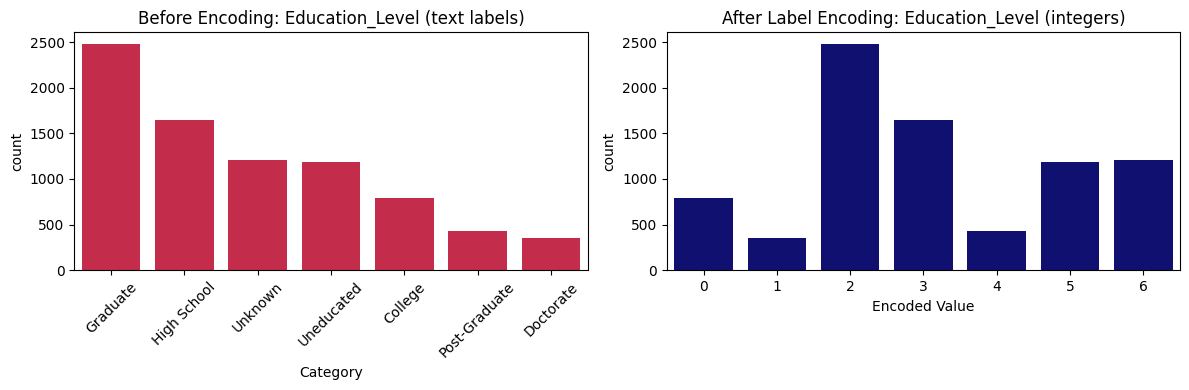

Plot successfully saved to: results/eda_visualizations/IT25102086_encoding_comparison.png


In [5]:
# Create the required before vs. after comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before encoding
sns.countplot(x=X_train['Education_Level'], order=X_train['Education_Level'].value_counts().index, ax=axes[0], color='crimson')
axes[0].set_title('Before Encoding: Education_Level (text labels)')
axes[0].set_xlabel('Category')
axes[0].tick_params(axis='x', rotation=45)

# After encoding
sns.countplot(x=X_train_encoded['Education_Level'], ax=axes[1], color='navy')
axes[1].set_title('After Label Encoding: Education_Level (integers)')
axes[1].set_xlabel('Encoded Value')

plt.tight_layout()

# Save image file to deliverable directory
plot_path = 'results/eda_visualizations/IT25102086_encoding_comparison.png'
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Plot successfully saved to: {plot_path}")
